In [63]:
# Read csv into pandas
import pandas as pd
# Had to remove manually the first two lines since they where 2 elements long
df_untouched = pd.read_csv('API_PV.EST_DS2_en_csv_v2_632380.csv')

In [64]:
# Make a copy of the untouched DataFrame
df = df_untouched.copy()

# Selection of countries
countries = ['Italy', 'Switzerland', 'France', 'Poland',]
df = df[df['Country Name'].isin(countries)]
# Selection of years
years = [str(year) for year in range(2002, 2024)]
df = df[['Country Name'] + years]

print(df.head())

    Country Name      2002      2003      2004      2005      2006      2007  \
37   Switzerland  1.542368  1.246109  1.227340  1.196782  1.268117  1.234409   
77        France  0.924183  0.179551  0.345115  0.399724  0.595506  0.563001   
116        Italy  0.838430  0.431488  0.269258  0.489116  0.530734  0.446970   
190       Poland  0.743998  0.578085  0.153858  0.363083  0.354032  0.682846   

         2008      2009      2010  ...      2014      2015      2016  \
37   1.222245  1.307721  1.258594  ...  1.402653  1.326494  1.289854   
77   0.543759  0.512013  0.681088  ...  0.300568  0.097760 -0.106350   
116  0.547544  0.346906  0.473924  ...  0.458165  0.363257  0.355933   
190  0.911096  0.938135  1.017330  ...  0.842941  0.862319  0.496158   

         2017      2018      2019      2020      2021      2022      2023  
37   1.242316  1.319482  1.310975  1.176240  1.115376  1.159745  1.071444  
77   0.265702  0.013894  0.271341  0.280993  0.325612  0.393339  0.343698  
116  0.292

In [65]:
# Save to a new CSV file
df.to_csv('Stability_and_Absence_of_Violence.csv', index=False)

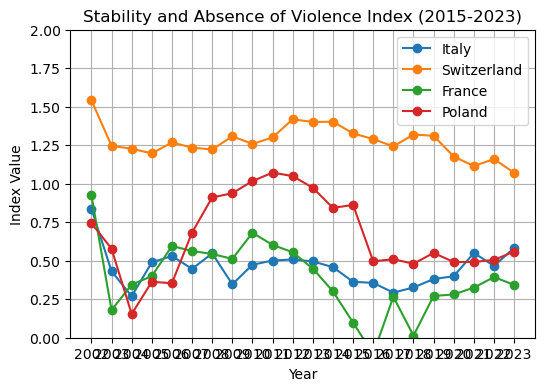

In [66]:
# Plot the data
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6,4))
for country in countries:
    plt.plot(years, df[df['Country Name'] == country].iloc[0, 1:], marker='o', label=country)
plt.title('Stability and Absence of Violence Index (2015-2023)')
plt.xlabel('Year')
plt.ylabel('Index Value')
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()


Italy predictions for 2030: [0.40447496]
Switzerland predictions for 2030: [1.19283726]
France predictions for 2030: [0.16744215]
Poland predictions for 2030: [0.62610889]


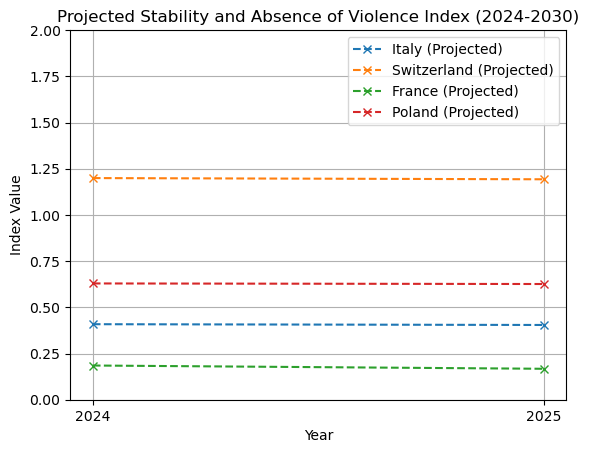

In [67]:
# linear extrapolation up to 2030
from sklearn.linear_model import LinearRegression
future_years = [str(year) for year in range(2024, 2026)]
for country in countries:
    country_data = df[df['Country Name'] == country].iloc[0, 1:].values.reshape(-1, 1)
    X = np.array([int(year) for year in years]).reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, country_data)
    future_X = np.array([int(year) for year in future_years]).reshape(-1, 1)
    future_predictions = model.predict(future_X)
    print(f"{country} predictions for 2030: {future_predictions[-1]}")
    plt.plot(future_years, future_predictions, marker='x', linestyle='--', label=f'{country} (Projected)')
plt.title('Projected Stability and Absence of Violence Index (2024-2030)')
plt.xlabel('Year')
plt.ylabel('Index Value')
plt.ylim(0, 2)
plt.grid()
plt.legend()
plt.show()


In [68]:

# Weighted average with increasing weights for more recent years
weights = np.arange(1, len(years) + 1)
print("Weights:", weights)
df['Weighted Average'] = df[years].apply(lambda row: np.average(row, weights=weights), axis=1)
print(df[['Country Name', 'Weighted Average', '2023']])

Weights: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
    Country Name  Weighted Average      2023
37   Switzerland          1.251604  1.071444
77        France          0.326282  0.343698
116        Italy          0.442373  0.583321
190       Poland          0.654045  0.559585
